ok, potrzebuję zrobić analizę daty. Tutaj trochę notatek:

1. Po co wybierać pomiędzy CNN i SNN, kiedy można zrobić od razu SCNN? XDD

Dobra, bo ogólnie chcę zrobić mały eksperymrnt z architekturą sieci neuronowej. Bo zobaczyłam taki układ w tutoriale do snntorch-a. Chcę potem porównać z samym snn.

2.


In [8]:
!pip install PyDrive
!pip install tonic
!pip install snntorch

In [9]:
import torchvision
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import snntorch as snn
from snntorch import surrogate
from snntorch import functional as SF
from snntorch import spikeplot as splt
from torch import nn
import tonic
from torch.utils.data import DataLoader, random_split
import tonic.transforms as transforms
from tonic import DiskCachedDataset
import random

In [10]:
#cuda setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
#seed setup
SEED = 42
random.seed(SEED) #dla każdej biblioteki ustawiamy seed'a osobno
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


device: cuda


In [15]:
setup = {
    "beta" : 0.9,
    "spike_grad" : surrogate.fast_sigmoid(slope=5), #f-ja aktywacji
    "img_size" : (128, 128),
    "data_root" : "./cache/ncaltech101",
    "lr" : 2e-3,
    "batch_size" : 67,
    "num_workers" : 2,
    "epochs" : 10
}

In [19]:
sensor_size = (240, 180, 2)
frame_transform = transforms.Compose([
    transforms.Downsample(sensor_size=sensor_size, target_size=setup["img_size"]),
    # transforms.RandomFlr(), # Removed: This transform does not exist in tonic.transforms
    # transforms.RandomRotation(angles=[-10, 10]), # Add random rotation within -10 to 10 degrees
    transforms.ToFrame(sensor_size=(setup["img_size"][0], setup["img_size"][1], 2), n_time_bins=20),
    lambda x: torch.from_numpy(x).float()
])

#downloading dataset

dataset = tonic.datasets.NCALTECH101(save_to='./data', transform=frame_transform)
cached_dataset = DiskCachedDataset(dataset, cache_path='./cache/ncaltech101')
all_loader = DataLoader(cached_dataset, batch_size=16, shuffle=True)

#dividing dataset into training and test(I decided to not add evaluation part)
train_size = int(0.8 * len(cached_dataset))
test_size = len(cached_dataset) - train_size

train_dataset, test_dataset = random_split(cached_dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=setup["batch_size"], shuffle=True, num_workers=setup["num_workers"])
test_loader = DataLoader(test_dataset, batch_size=setup["batch_size"], shuffle=False, num_workers=setup["num_workers"])

In [22]:
#warstwy SCNN'u
#zrób po testach: spróbuj zmienić flatten+linear na AdaptiveAvgPool2d.
#Dodaj też potem jak coś jescze jeden blok, jeżeli będzie źle

import os # Import os module to handle file paths

class SCNNetwork(nn.Module):
  def __init__(self, inp_ch = 2, outp_ch = 101, kern_s = 3, strd = 1, pd = 1, bs = False, bet = setup["beta"]):
    super().__init__()
    self.conv1 = nn.Conv2d(inp_ch, inp_ch*8, kernel_size = kern_s, stride = strd, padding = pd, bias = bs)
    self.conv2 = nn.Conv2d(inp_ch*8, inp_ch*16, kernel_size = kern_s, stride = strd, padding = pd)
    self.flatten = nn.Flatten()
    # Corrected linear layer input size: 32x32 feature map * 32 channels (inp_ch*16)
    self.linear = nn.Linear(inp_ch*16*32*32, 101)
    self.leaky1 = snn.Leaky(beta=bet, spike_grad=setup["spike_grad"])
    self.leaky2 = snn.Leaky(beta=bet, spike_grad=setup["spike_grad"], output=True)
    self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
    self.dropout = nn.Dropout(p=0.5) # Add dropout layer with 50% probability

  def forward(self, x):
    mem1 = self.leaky1.init_leaky()
    mem2 = self.leaky1.init_leaky()
    mem3 = self.leaky2.init_leaky()

    num_steps = x.shape[1]

    spk3_rec = []
    mem3_rec = [] # Dodajemy listę na rejestrację potencjału

    for step in range(num_steps):
            x_step = x[:, step, :, :, :]

            #layer 1
            cur1 = self.conv1(x_step)
            cur1 = self.pool(cur1)
            spk1, mem1 = self.leaky1(cur1, mem1)
            spk1 = self.dropout(spk1)

            #layer 2
            cur2 = self.conv2(spk1)
            cur2 = self.pool(cur2)
            spk2, mem2 = self.leaky1(cur2, mem2)
            spk2 = self.dropout(spk2)

            #output
            out = self.flatten(spk2)
            out = self.linear(out)
            spk3, mem3 = self.leaky2(out, mem3)

            spk3_rec.append(spk3)
            mem3_rec.append(mem3)

    return torch.stack(spk3_rec, dim=0), torch.stack(mem3_rec, dim=0)

model = SCNNetwork().to(device) # Move model to device

# Dynamically get class names from the dataset directory structure
dataset_root_path = os.path.join('./data', 'NCALTECH101', 'Caltech101')
class_names = sorted([d for d in os.listdir(dataset_root_path) if os.path.isdir(os.path.join(dataset_root_path, d))])
class_to_idx = {cls_name: i for i, cls_name in enumerate(class_names)}

for data, raw_targets in train_loader:
    data = data.to(device) # Move data to device
    # Convert byte string targets to integer tensor targets
    target_indices = [class_to_idx[t.decode('utf-8')] for t in raw_targets]
    targets = torch.tensor(target_indices, dtype=torch.long).to(device)

    output_spikes, output_mem = model(data) # Unpack both spikes and membrane potentials

    # Calculate loss
    spike_counts = output_spikes.sum(dim=0)  # Shape: [16, 101]
    loss = nn.CrossEntropyLoss()(spike_counts, targets)
    break




old_sketch = '''def net(inp_ch = 2, outp_ch = 101, kern_s = 3, strd = 1, pd = 1, bs = False, bet = setup[beta]):
  net = nn.Sequential(nn.Conv2d(inp_ch, inp_ch*8, kernel_size = kern_s, stride = strd, padding = padding, bias = bs),
                      nn.MaxPool2d(kernel_size=2, stride=2),
                      snn.Leaky(beta=beta, spike_grad=spike_grad, init_hidden=True),
                      nn.Conv2d(inp_ch*8, inp_ch*16, kernel_size = kern_s, stride = strd, padding = pd),
                      nn.MaxPool2d(kernel_size=2, stride=2),
                      snn.Leaky(beta=beta, spike_grad=spike_grad, init_hidden=True),
                      nn.Flatten(),
                      nn.Linear(inp_ch*16*8*8, 101),
                      snn.Leaky(beta=beta, spike_grad=spike_grad, init_hidden=True, output=True)
                      ).to(device)
  return net''' #zdecydowałam jednak zrobić to przez zmienne dla większej wariatywności i łatwiejszego odczytywania

In [25]:
#training loop
model = SCNNetwork().to(device) # Re-instantiate the model with the latest SCNNetwork definition and move to device
optimizer = torch.optim.Adam(model.parameters(), lr=2e-3, betas=(0.9, 0.999))
loss_fn = SF.mse_count_loss(correct_rate=0.8, incorrect_rate=0.2)

#num_epochs = 1 # was for testing purposes
num_steps = 25  # run for 25 time steps

loss_hist = [] # record loss over iterations
acc_hist = [] # record accuracy over iterations

train_loss_hist = []
test_loss_hist = []
test_acc_hist = []

# training loop
for epoch in range(setup["epochs"]):
    for i, (data, raw_targets) in enumerate(iter(train_loader)):
        data = data.to(device)
        # Convert byte string targets to integer tensor targets
        target_indices = [class_to_idx[t.decode('utf-8')] for t in raw_targets]
        targets = torch.tensor(target_indices, dtype=torch.long).to(device)

        model.train()
        spk_rec, mem_rec = model(data) # forward-pass, now correctly unpacking two values
        loss_val = loss_fn(spk_rec, targets) # loss calculation
        optimizer.zero_grad() # null gradients
        loss_val.backward() # calculate gradients
        optimizer.step() # update weights
        loss_hist.append(loss_val.item()) # store loss

        # print every 25 iterations
        if i % 25 == 0:
          model.eval()
          print(f"Epoch {epoch}, Iteration {i} \nTrain Loss: {loss_val.item():.2f}")

    model.eval()
    test_loss_total = 0
    test_acc_total = 0

    with torch.no_grad(): # Wyłączenie śledzenia gradientów dla oszczędności pamięci i czasu
        for data, raw_targets in test_loader:
            data = data.to(device)
            target_indices = [class_to_idx[t.decode('utf-8')] for t in raw_targets]
            targets = torch.tensor(target_indices, dtype=torch.long).to(device)

            spk_rec, mem_rec = model(data)

            loss_val = loss_fn(spk_rec, targets)
            test_loss_total += loss_val.item()
            test_acc_total += SF.accuracy_rate(spk_rec, targets)

    # Obliczenie średnich wartości dla całej epoki
    avg_test_loss = test_loss_total / len(test_loader)
    avg_test_acc = test_acc_total / len(test_loader)

    test_loss_hist.append(avg_test_loss)
    test_acc_hist.append(avg_test_acc)

    print(f"Test Loss: {avg_test_loss:.2f}")
    print(f"Test Accuracy: {avg_test_acc:.2f}")

Epoch 0, Iteration 0 
Train Loss: 0.78
Epoch 0, Iteration 25 
Train Loss: 0.92
Epoch 0, Iteration 50 
Train Loss: 1.15
Epoch 0, Iteration 75 
Train Loss: 0.18
Epoch 0, Iteration 100 
Train Loss: 0.10
Test Loss: 0.89
Test Accuracy: 0.19
Epoch 1, Iteration 0 
Train Loss: 0.13
Epoch 1, Iteration 25 
Train Loss: 0.09
Epoch 1, Iteration 50 
Train Loss: 0.10
Epoch 1, Iteration 75 
Train Loss: 0.09
Epoch 1, Iteration 100 
Train Loss: 0.10
Test Loss: 0.83
Test Accuracy: 0.24
Epoch 2, Iteration 0 
Train Loss: 0.08
Epoch 2, Iteration 25 
Train Loss: 0.08
Epoch 2, Iteration 50 
Train Loss: 0.09
Epoch 2, Iteration 75 
Train Loss: 0.08
Epoch 2, Iteration 100 
Train Loss: 0.10
Test Loss: 0.64
Test Accuracy: 0.26
Epoch 3, Iteration 0 
Train Loss: 0.07
Epoch 3, Iteration 25 
Train Loss: 0.09
Epoch 3, Iteration 50 
Train Loss: 0.07
Epoch 3, Iteration 75 
Train Loss: 0.09
Epoch 3, Iteration 100 
Train Loss: 0.07
Test Loss: 0.35
Test Accuracy: 0.27
Epoch 4, Iteration 0 
Train Loss: 0.09
Epoch 4, Iteratio

#WIZUALIZACJA

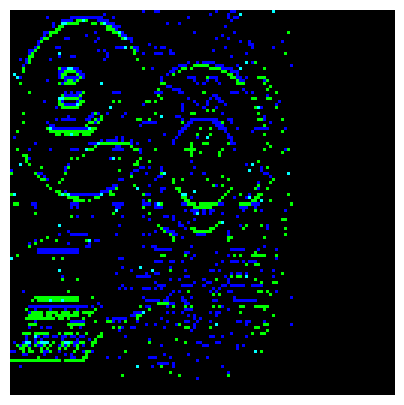

In [26]:
#animation


#one sample
events, label = dataset[0]
tonic.utils.plot_animation(events)

/tmp/ipykernel_7897/4191519652.py:33: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


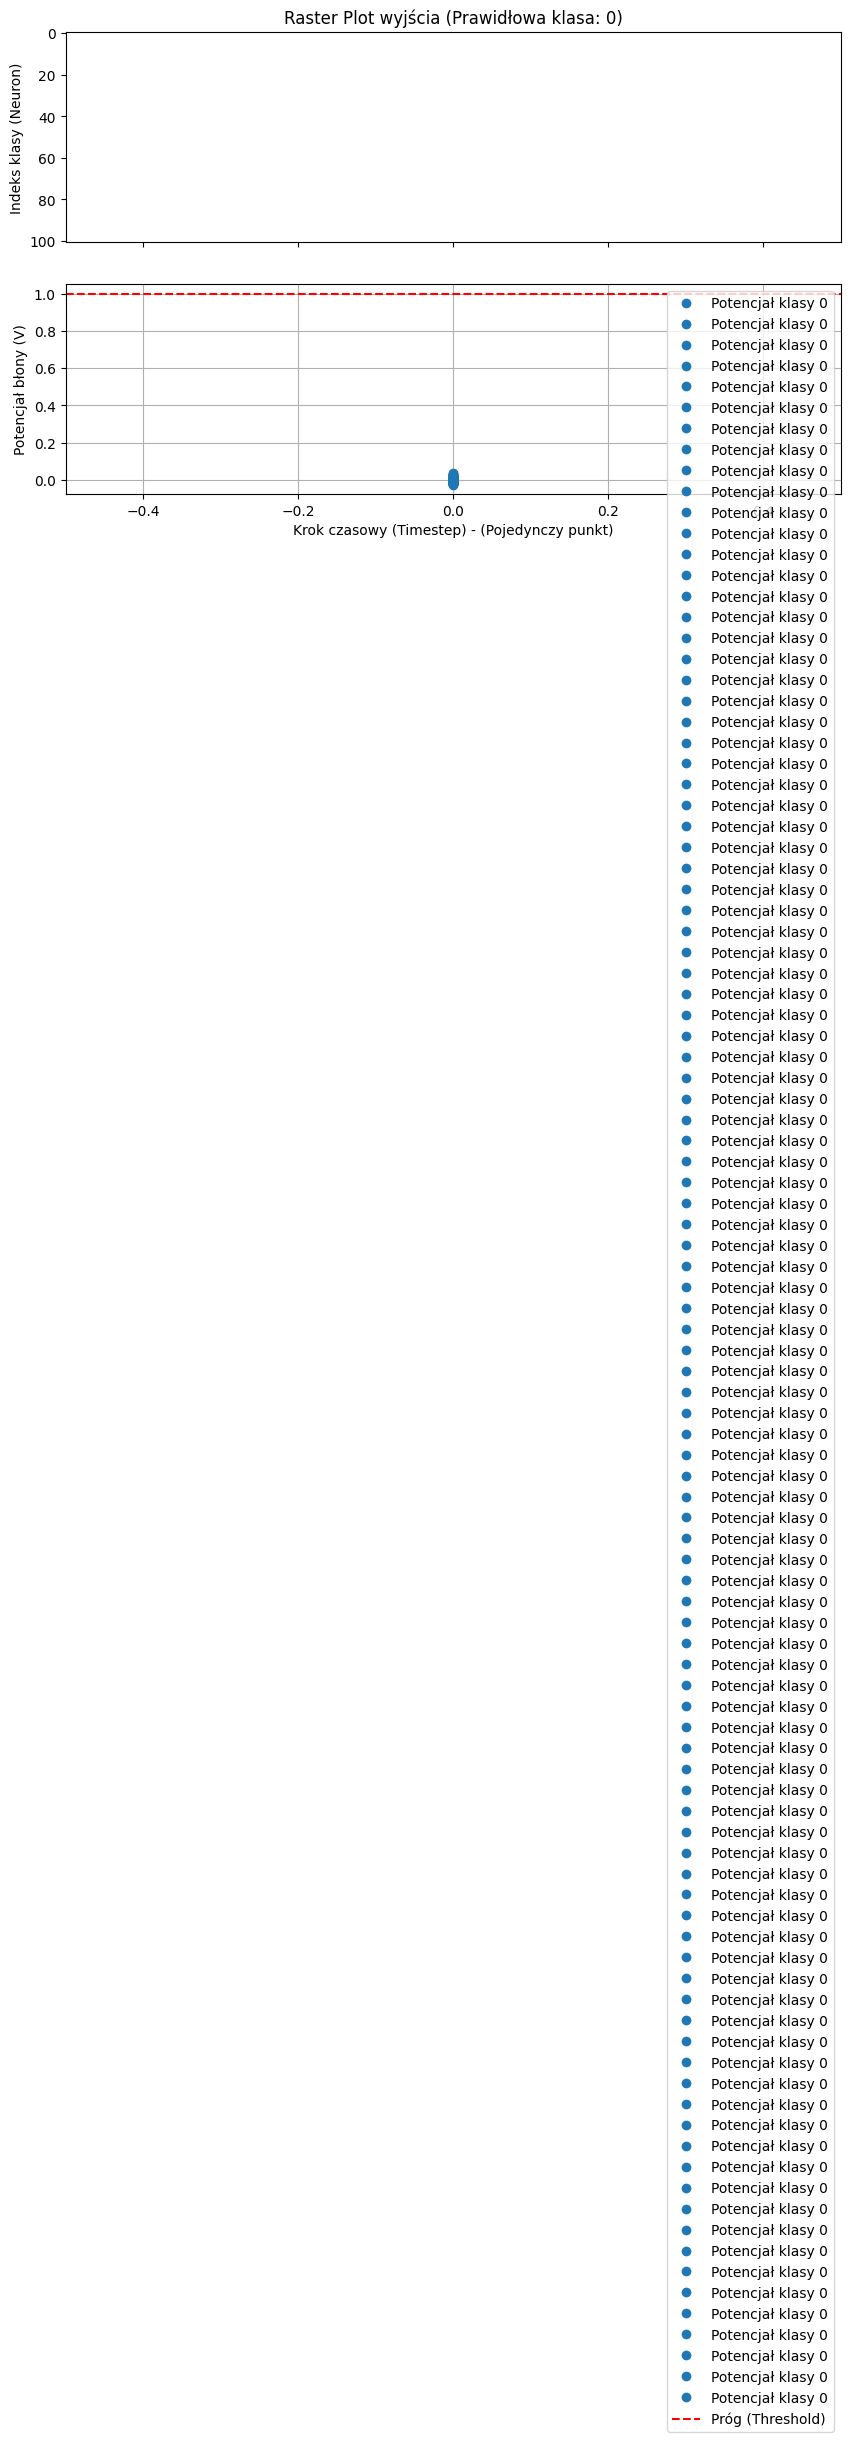

In [27]:
#output visual
import matplotlib.pyplot as plt
import numpy as np

def plot_snn_output(spk_rec, mem_rec, sample_idx=0, target_class=None):
    """
    spk_rec: Tensor o kształcie [num_steps, batch_size, num_classes]
    mem_rec: Tensor o kształcie [batch_size, num_classes] (obecnie, jeśli pochodzi z pojedynczego timestepu)
    """
    spikes = spk_rec[:, sample_idx, :].detach().cpu().numpy()  # [num_steps, num_classes]
    # Zmieniono indeksowanie mem_rec, ponieważ output_mem jest 2D ([batch_size, num_classes])
    mem = mem_rec[sample_idx, :].detach().cpu().numpy() # [num_classes]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

    # Raster Plot – czarne kreski oznaczają wystąpienie iglicy
    ax1.imshow(spikes.T, cmap='binary', aspect='auto', interpolation='nearest')
    ax1.set_ylabel("Indeks klasy (Neuron)")
    ax1.set_title(f"Raster Plot wyjścia (Prawidłowa klasa: {target_class})")

    # Potencjał błony dla prawidłowej klasy (teraz pojedyncza wartość)
    if target_class is not None:
        # Plot a single point for the final membrane potential
        ax2.plot([0], [mem[target_class]], 'o', label=f'Potencjał klasy {target_class}', color='tab:blue')
        ax2.axhline(y=1.0, color='r', linestyle='--', label='Próg (Threshold)')
        ax2.set_xlabel("Krok czasowy (Timestep) - (Pojedynczy punkt)") # Etykieta dostosowana
        ax2.set_ylabel("Potencjał błony (V)")
        ax2.legend()
        ax2.grid(True)
        # Ustawienie limitu osi X, aby punkt był widoczny
        ax2.set_xlim(-0.5, 0.5)

    plt.tight_layout()
    plt.show()

plot_snn_output(output_spikes, output_mem, target_class=0)

In [29]:
def plot_snn_output(spk_rec, mem_rec, sample_idx=0, target_class=None):
    """
    spk_rec: Tensor o kształcie [num_steps, batch_size, num_classes]
    mem_rec: Tensor o kształcie [num_steps, batch_size, num_classes]
    """
    spikes = spk_rec[:, sample_idx, :].detach().cpu().numpy()  # [num_steps, num_classes]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

    # Raster Plot – czarne kreski oznaczają wystąpienie iglicy
    ax1.imshow(spikes.T, cmap='binary', aspect='auto', interpolation='nearest')
    ax1.set_ylabel("Indeks klasy (Neuron)")
    ax1.set_title(f"Raster Plot wyjścia (Prawidłowa klasa: {target_class})")

    # Potencjał błony dla prawidłowej klasy (pełna oś czasu)
    if target_class is not None:
        # Pobieramy pełną historię czasową potencjału membrany dla wybranej klasy
        mem_trace = mem_rec[:, sample_idx, target_class].detach().cpu().numpy()

        ax2.plot(mem_trace, label=f'Potencjał klasy {target_class}', color='tab:blue')
        ax2.axhline(y=1.0, color='r', linestyle='--', label='Próg (Threshold)')
        ax2.set_xlabel("Krok czasowy (Timestep)")
        ax2.set_ylabel("Potencjał błony (V)")
        ax2.legend()
        ax2.grid(True)
        # Usunięto sztywne set_xlim, aby wykres dopasował się do całej długości kroków (np. 25 lub więcej)[cite: 1]

    plt.tight_layout()
    plt.show()

Generating visualizations...


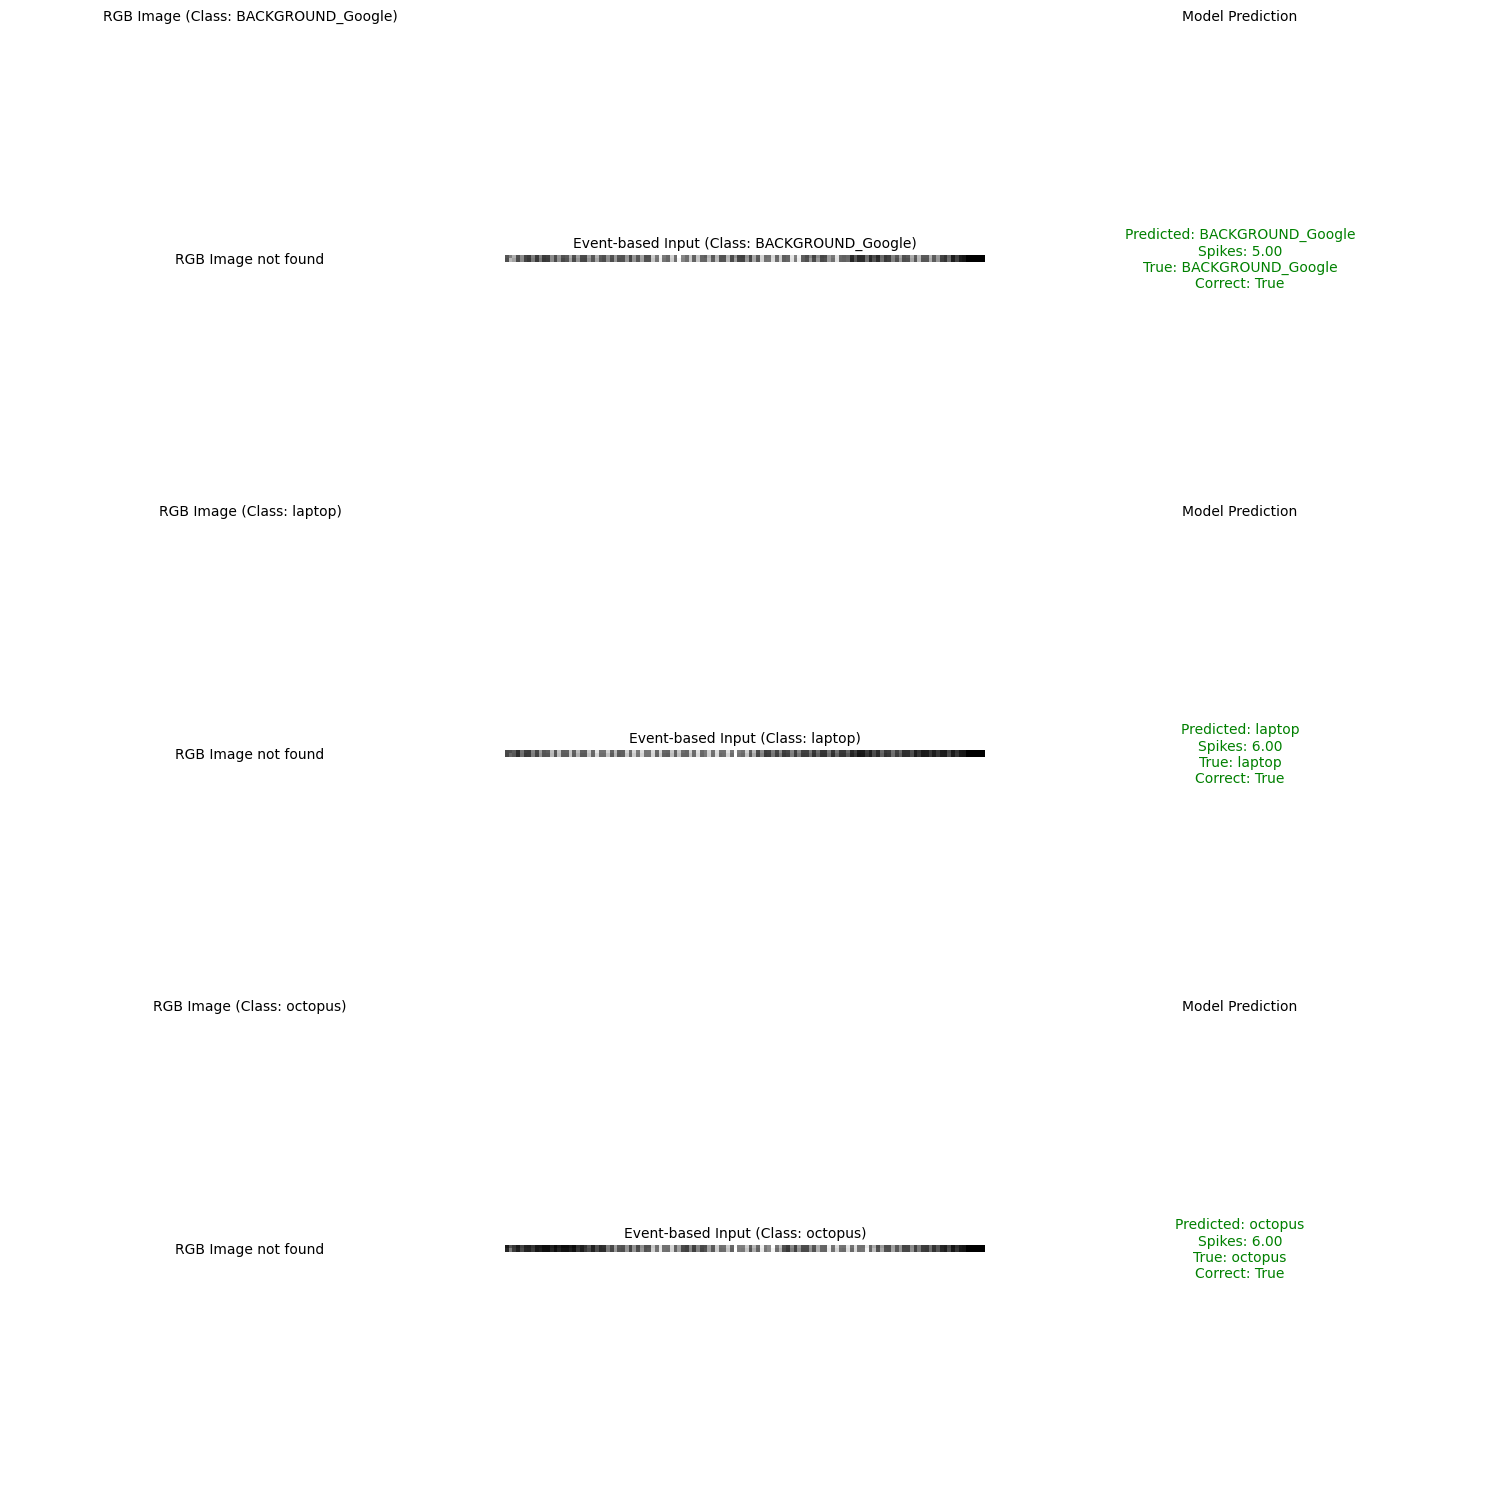

In [30]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import random
import os

# Ensure the model is in evaluation mode
model.eval()

# Function to get an original RGB image for a given class name
def get_random_rgb_image_for_class(class_name, dataset_root):
    class_path = os.path.join(dataset_root, class_name)
    if os.path.isdir(class_path):
        image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]
        if image_files:
            random_image_path = os.path.join(class_path, random.choice(image_files))
            try:
                img = Image.open(random_image_path).convert('RGB')
                return img
            except Exception as e:
                print(f"Error loading image {random_image_path}: {e}")
    return None

def visualize_model_comparison(model, train_loader, class_to_idx, class_names, dataset_root_path, device, img_size, num_comparisons=3):
    model.eval() # Ensure model is in evaluation mode
    fig, axes = plt.subplots(num_comparisons, 3, figsize=(15, 5 * num_comparisons))

    # Handle single comparison case for consistent indexing
    if num_comparisons == 1:
        axes = axes.reshape(1, -1)

    # Use an iterator for train_loader to get distinct samples for each comparison
    data_iter = iter(train_loader)

    print("Generating visualizations...")

    for i in range(num_comparisons):
        try:
            data_batch, raw_targets_batch = next(data_iter)
        except StopIteration:
            print("Not enough samples in train_loader for the requested number of comparisons.")
            break

        # Pick a random sample from the batch
        sample_idx = random.randint(0, data_batch.shape[0] - 1)
        data_sample = data_batch[sample_idx].unsqueeze(0).to(device) # Get one sample and add batch dim
        raw_target = raw_targets_batch[sample_idx]
        target_class_name = raw_target.decode('utf-8')
        target_idx = class_to_idx[target_class_name]

        # --- Column 1: Original RGB Image ---
        rgb_img = get_random_rgb_image_for_class(target_class_name, dataset_root_path)
        if rgb_img:
            # Resize RGB image to match the event-based input size
            rgb_img_resized = rgb_img.resize(img_size)
            axes[i, 0].imshow(rgb_img_resized)
            axes[i, 0].set_title(f"RGB Image (Class: {target_class_name})", fontsize=10)
            axes[i, 0].axis('off')
        else:
            axes[i, 0].text(0.5, 0.5, "RGB Image not found", ha='center', va='center', transform=axes[i, 0].transAxes, fontsize=10)
            axes[i, 0].set_title(f"RGB Image (Class: {target_class_name})", fontsize=10)
            axes[i, 0].axis('off')

        # --- Column 2: Event-based representation (summed frame) ---
        # data_sample has shape [1 (batch), num_steps, H, W, C]
        # Sum over num_steps and channels to get a single grayscale image
        event_frame = data_sample.squeeze(0).cpu().sum(dim=0).sum(dim=-1).numpy() # sum over time and channels
        # Normalize for display to [0,1]
        if event_frame.max() > event_frame.min():
            event_frame = (event_frame - event_frame.min()) / (event_frame.max() - event_frame.min())
        else:
            event_frame = np.zeros_like(event_frame) # Handle case where all values are the same (e.g., no events)

        axes[i, 1].imshow(event_frame, cmap='gray')
        axes[i, 1].set_title(f"Event-based Input (Class: {target_class_name})", fontsize=10)
        axes[i, 1].axis('off')

        # --- Column 3: Model Output Prediction ---
        with torch.no_grad():
            output_spikes, _ = model(data_sample) # [num_steps, 1 (batch), num_classes]

        # Sum spikes over time steps to get total spikes per class
        total_spikes_per_class = output_spikes.sum(dim=0).squeeze(0) # [num_classes]
        predicted_class_idx = torch.argmax(total_spikes_per_class).item()
        predicted_class_name = class_names[predicted_class_idx]

        is_correct = (predicted_class_idx == target_idx)
        prediction_color = 'green' if is_correct else 'red'

        # Determine the confidence (e.g., spike count for predicted class)
        predicted_spike_count = total_spikes_per_class[predicted_class_idx].item()

        prediction_text = f"Predicted: {predicted_class_name}\n" \
                          f"Spikes: {predicted_spike_count:.2f}\n" \
                          f"True: {target_class_name}\n" \
                          f"Correct: {is_correct}"

        axes[i, 2].text(0.5, 0.5, prediction_text, ha='center', va='center', wrap=True,
                       transform=axes[i, 2].transAxes, fontsize=10, color=prediction_color)
        axes[i, 2].set_title("Model Prediction", fontsize=10)
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()

# Call the function with global variables
visualize_model_comparison(model, train_loader, class_to_idx, class_names, dataset_root_path, device, setup["img_size"], num_comparisons=3)